# Phase One: Preprocessing
BOM dataset

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import MinMaxScaler,OrdinalEncoder
from sklearn.model_selection import train_test_split

In [27]:
import pandas as pd
df = pd.read_csv('../Dataset/BOM.csv')
display(df)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


First we want to work with the first column, date!<br>
because i think the year and month and day of the week through the dataset of the rain for tomorrow is very effective.<br>
To connect the last day of the week to the first of the week (and it goes for month too) we use sin/cos.

In [28]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

df = df.drop(columns=['Date', 'Month', 'DayOfWeek'])

df

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,NaN,16.9,21.8,No,No,2008,-2.449294e-16,1.0,0.000000,1.000000
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,NaN,17.2,24.3,No,No,2008,-2.449294e-16,1.0,0.781831,0.623490
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,2.0,21.0,23.2,No,No,2008,-2.449294e-16,1.0,0.974928,-0.222521
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,NaN,18.1,26.5,No,No,2008,-2.449294e-16,1.0,0.433884,-0.900969
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,8.0,17.8,29.7,No,No,2008,-2.449294e-16,1.0,-0.433884,-0.900969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,...,NaN,10.1,22.4,No,No,2017,1.224647e-16,-1.0,0.974928,-0.222521
145456,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,...,NaN,10.9,24.5,No,No,2017,1.224647e-16,-1.0,0.433884,-0.900969
145457,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,...,NaN,12.5,26.1,No,No,2017,1.224647e-16,-1.0,-0.433884,-0.900969
145458,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,N,...,2.0,15.1,26.0,No,No,2017,1.224647e-16,-1.0,-0.974928,-0.222521


now about the second feature that we have: location!<br>
i want to found if there are how many unique location that we have!

In [29]:
# df['Location'].nunique()
df['Location'].value_counts()

Location
Canberra            3436
Sydney              3344
Adelaide            3193
Darwin              3193
Hobart              3193
Perth               3193
Melbourne           3193
Brisbane            3193
Albury              3040
MountGinini         3040
GoldCoast           3040
Wollongong          3040
MountGambier        3040
Launceston          3040
AliceSprings        3040
Albany              3040
Townsville          3040
Bendigo             3040
Cairns              3040
Ballarat            3040
Penrith             3039
Newcastle           3039
Tuggeranong         3039
PerthAirport        3009
Williamtown         3009
Cobar               3009
BadgerysCreek       3009
SydneyAirport       3009
Richmond            3009
Moree               3009
CoffsHarbour        3009
NorfolkIsland       3009
WaggaWagga          3009
Witchcliffe         3009
Watsonia            3009
Dartmoor            3009
Portland            3009
Sale                3009
MelbourneAirport    3009
Mildura         

these are the cities in Australia. i think it is the best to set them with the geographical location! i will sets in latitude and longitude!

i wanted to use `geopy` library but because of the Internet it gives an `HTTPSConnectionPool` error!<br>
so i get the actual lat and lon form ChatGPT!

In [30]:
coords_dict = {
    'Albury': (-36.0737, 146.9135),
    'BadgerysCreek': (-33.8800, 150.7300),
    'Cobar': (-31.4983, 145.8389),
    'CoffsHarbour': (-30.2963, 153.1135),
    'Moree': (-29.4633, 149.8458),
    'Newcastle': (-32.9283, 151.7817),
    'NorahHead': (-33.2800, 151.5700),
    'NorfolkIsland': (-29.0408, 167.9547),
    'Penrith': (-33.7510, 150.6942),
    'Richmond': (-33.5997, 150.7517),
    'Sydney': (-33.8688, 151.2093),
    'SydneyAirport': (-33.9399, 151.1753),
    'WaggaWagga': (-35.1082, 147.3598),
    'Williamtown': (-32.8150, 151.8428),
    'Wollongong': (-34.4278, 150.8931),
    'Canberra': (-35.2809, 149.1300),
    'Tuggeranong': (-35.4244, 149.0638),
    'MountGinini': (-35.5294, 148.7728),
    'Ballarat': (-37.5622, 143.8503),
    'Bendigo': (-36.7570, 144.2794),
    'Sale': (-38.1067, 147.0665),
    'MelbourneAirport': (-37.6690, 144.8410),
    'Melbourne': (-37.8136, 144.9631),
    'Mildura': (-34.1856, 142.1617),
    'Nhil': (-36.3333, 141.6500),
    'Portland': (-38.3458, 141.6042),
    'Watsonia': (-37.7100, 145.0831),
    'Dartmoor': (-37.9167, 141.2667),
    'Brisbane': (-27.4698, 153.0251),
    'Cairns': (-16.9186, 145.7781),
    'GoldCoast': (-28.0167, 153.4000),
    'Townsville': (-19.2589, 146.8169),
    'Adelaide': (-34.9285, 138.6007),
    'MountGambier': (-37.8283, 140.7833),
    'Nuriootpa': (-34.4667, 138.9833),
    'Woomera': (-31.1558, 136.8014),
    'Albany': (-35.0269, 117.8837),
    'Witchcliffe': (-34.0267, 115.1000),
    'PearceRAAF': (-31.6678, 116.0178),
    'PerthAirport': (-31.9385, 115.9672),
    'Perth': (-31.9505, 115.8605),
    'SalmonGums': (-32.9833, 121.6333),
    'Walpole': (-34.9767, 116.7317),
    'Hobart': (-42.8826, 147.3257),
    'Launceston': (-41.4388, 147.1347),
    'AliceSprings': (-23.6980, 133.8807),
    'Darwin': (-12.4634, 130.8456),
    'Katherine': (-14.4652, 132.2635),
    'Uluru': (-25.3444, 131.0369),
}

df['Lat'] = df['Location'].map(lambda x: coords_dict.get(x, (None, None))[0])
df['Lon'] = df['Location'].map(lambda x: coords_dict.get(x, (None, None))[1])

df = df.drop(columns=['Location'])
df


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Temp3pm,RainToday,RainTomorrow,Year,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,Lat,Lon
0,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,...,21.8,No,No,2008,-2.449294e-16,1.0,0.000000,1.000000,-36.0737,146.9135
1,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,...,24.3,No,No,2008,-2.449294e-16,1.0,0.781831,0.623490,-36.0737,146.9135
2,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,...,23.2,No,No,2008,-2.449294e-16,1.0,0.974928,-0.222521,-36.0737,146.9135
3,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,...,26.5,No,No,2008,-2.449294e-16,1.0,0.433884,-0.900969,-36.0737,146.9135
4,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,...,29.7,No,No,2008,-2.449294e-16,1.0,-0.433884,-0.900969,-36.0737,146.9135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,13.0,...,22.4,No,No,2017,1.224647e-16,-1.0,0.974928,-0.222521,-25.3444,131.0369
145456,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,13.0,...,24.5,No,No,2017,1.224647e-16,-1.0,0.433884,-0.900969,-25.3444,131.0369
145457,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,9.0,...,26.1,No,No,2017,1.224647e-16,-1.0,-0.433884,-0.900969,-25.3444,131.0369
145458,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,N,13.0,...,26.0,No,No,2017,1.224647e-16,-1.0,-0.974928,-0.222521,-25.3444,131.0369


In [31]:
df.isna().sum()

MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
Year                 0
Month_sin            0
Month_cos            0
DayOfWeek_sin        0
DayOfWeek_cos        0
Lat                  0
Lon                  0
dtype: int64

Now what were going to do with this all data that we miss!<br>
and when we should split train and test? because we don't want to normalize the train data with test data! 

In [32]:
df.isnull().sum()
df.isnull().mean() * 100

MinTemp           1.020899
MaxTemp           0.866905
Rainfall          2.241853
Evaporation      43.166506
Sunshine         48.009762
WindGustDir       7.098859
WindGustSpeed     7.055548
WindDir9am        7.263853
WindDir3pm        2.906641
WindSpeed9am      1.214767
WindSpeed3pm      2.105046
Humidity9am       1.824557
Humidity3pm       3.098446
Pressure9am      10.356799
Pressure3pm      10.331363
Cloud9am         38.421559
Cloud3pm         40.807095
Temp9am           1.214767
Temp3pm           2.481094
RainToday         2.241853
RainTomorrow      2.245978
Year              0.000000
Month_sin         0.000000
Month_cos         0.000000
DayOfWeek_sin     0.000000
DayOfWeek_cos     0.000000
Lat               0.000000
Lon               0.000000
dtype: float64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 28 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   MinTemp        143975 non-null  float64
 1   MaxTemp        144199 non-null  float64
 2   Rainfall       142199 non-null  float64
 3   Evaporation    82670 non-null   float64
 4   Sunshine       75625 non-null   float64
 5   WindGustDir    135134 non-null  object 
 6   WindGustSpeed  135197 non-null  float64
 7   WindDir9am     134894 non-null  object 
 8   WindDir3pm     141232 non-null  object 
 9   WindSpeed9am   143693 non-null  float64
 10  WindSpeed3pm   142398 non-null  float64
 11  Humidity9am    142806 non-null  float64
 12  Humidity3pm    140953 non-null  float64
 13  Pressure9am    130395 non-null  float64
 14  Pressure3pm    130432 non-null  float64
 15  Cloud9am       89572 non-null   float64
 16  Cloud3pm       86102 non-null   float64
 17  Temp9am        143693 non-nul

In [34]:
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Temp3pm,RainToday,RainTomorrow,Year,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,Lat,Lon
0,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,...,21.8,0.0,No,2008,-2.449294e-16,1.0,0.000000,1.000000,-36.0737,146.9135
1,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,...,24.3,0.0,No,2008,-2.449294e-16,1.0,0.781831,0.623490,-36.0737,146.9135
2,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,...,23.2,0.0,No,2008,-2.449294e-16,1.0,0.974928,-0.222521,-36.0737,146.9135
3,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,...,26.5,0.0,No,2008,-2.449294e-16,1.0,0.433884,-0.900969,-36.0737,146.9135
4,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,...,29.7,0.0,No,2008,-2.449294e-16,1.0,-0.433884,-0.900969,-36.0737,146.9135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,13.0,...,22.4,0.0,No,2017,1.224647e-16,-1.0,0.974928,-0.222521,-25.3444,131.0369
145456,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,13.0,...,24.5,0.0,No,2017,1.224647e-16,-1.0,0.433884,-0.900969,-25.3444,131.0369
145457,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,9.0,...,26.1,0.0,No,2017,1.224647e-16,-1.0,-0.433884,-0.900969,-25.3444,131.0369
145458,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,N,13.0,...,26.0,0.0,No,2017,1.224647e-16,-1.0,-0.974928,-0.222521,-25.3444,131.0369


each wind direction has a number that we can use! instead of what it is right now!

In [35]:
direction_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}

for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
    df[col + '_deg'] = df[col].map(direction_map)
    df[col + '_sin'] = np.sin(np.radians(df[col + '_deg']))
    df[col + '_cos'] = np.cos(np.radians(df[col + '_deg']))
    df.drop([col, col + '_deg'], axis=1, inplace=True)

df

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,DayOfWeek_sin,DayOfWeek_cos,Lat,Lon,WindGustDir_sin,WindGustDir_cos,WindDir9am_sin,WindDir9am_cos,WindDir3pm_sin,WindDir3pm_cos
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,...,0.000000,1.000000,-36.0737,146.9135,-1.000000,-1.836970e-16,-1.000000,-1.836970e-16,-0.923880,3.826834e-01
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,...,0.781831,0.623490,-36.0737,146.9135,-0.923880,3.826834e-01,-0.382683,9.238795e-01,-0.923880,-3.826834e-01
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,...,0.974928,-0.222521,-36.0737,146.9135,-0.923880,-3.826834e-01,-1.000000,-1.836970e-16,-0.923880,-3.826834e-01
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,...,0.433884,-0.900969,-36.0737,146.9135,0.707107,7.071068e-01,0.707107,-7.071068e-01,1.000000,6.123234e-17
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,...,-0.433884,-0.900969,-36.0737,146.9135,-1.000000,-1.836970e-16,0.923880,3.826834e-01,-0.707107,7.071068e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2.8,23.4,0.0,NaN,NaN,31.0,13.0,11.0,51.0,24.0,...,0.974928,-0.222521,-25.3444,131.0369,1.000000,6.123234e-17,0.707107,-7.071068e-01,0.923880,3.826834e-01
145456,3.6,25.3,0.0,NaN,NaN,22.0,13.0,9.0,56.0,21.0,...,0.433884,-0.900969,-25.3444,131.0369,-0.382683,9.238795e-01,0.707107,-7.071068e-01,0.000000,1.000000e+00
145457,5.4,26.9,0.0,NaN,NaN,37.0,9.0,9.0,53.0,24.0,...,-0.433884,-0.900969,-25.3444,131.0369,0.000000,1.000000e+00,0.707107,-7.071068e-01,-0.923880,3.826834e-01
145458,7.8,27.0,0.0,NaN,NaN,28.0,13.0,7.0,51.0,24.0,...,-0.974928,-0.222521,-25.3444,131.0369,0.707107,-7.071068e-01,0.382683,-9.238795e-01,0.000000,1.000000e+00


In [36]:
numeric_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 
                'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
                'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

In [37]:
missing_pct = df[numeric_cols].isnull().mean() * 100

low_missing = missing_pct[missing_pct < 5].index.tolist()
med_missing = missing_pct[(missing_pct >= 5) & (missing_pct < 30)].index.tolist()
high_missing = missing_pct[missing_pct >= 30].index.tolist()

i want to do as this strategy:
- less than 5% empty: median/mean
- 5% to 30% empty: KNNImputer
- more than 30% empty: median + flag!

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 31 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   MinTemp          143975 non-null  float64
 1   MaxTemp          144199 non-null  float64
 2   Rainfall         142199 non-null  float64
 3   Evaporation      82670 non-null   float64
 4   Sunshine         75625 non-null   float64
 5   WindGustSpeed    135197 non-null  float64
 6   WindSpeed9am     143693 non-null  float64
 7   WindSpeed3pm     142398 non-null  float64
 8   Humidity9am      142806 non-null  float64
 9   Humidity3pm      140953 non-null  float64
 10  Pressure9am      130395 non-null  float64
 11  Pressure3pm      130432 non-null  float64
 12  Cloud9am         89572 non-null   float64
 13  Cloud3pm         86102 non-null   float64
 14  Temp9am          143693 non-null  float64
 15  Temp3pm          141851 non-null  float64
 16  RainToday        142199 non-null  floa

In [39]:
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow'].map({'No': 0, 'Yes': 1})
y

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
145455    0.0
145456    0.0
145457    0.0
145458    0.0
145459    NaN
Name: RainTomorrow, Length: 145460, dtype: float64

In [40]:
df.isna().sum()

MinTemp             1485
MaxTemp             1261
Rainfall            3261
Evaporation        62790
Sunshine           69835
WindGustSpeed      10263
WindSpeed9am        1767
WindSpeed3pm        3062
Humidity9am         2654
Humidity3pm         4507
Pressure9am        15065
Pressure3pm        15028
Cloud9am           55888
Cloud3pm           59358
Temp9am             1767
Temp3pm             3609
RainToday           3261
RainTomorrow        3267
Year                   0
Month_sin              0
Month_cos              0
DayOfWeek_sin          0
DayOfWeek_cos          0
Lat                    0
Lon                    0
WindGustDir_sin    10326
WindGustDir_cos    10326
WindDir9am_sin     10566
WindDir9am_cos     10566
WindDir3pm_sin      4228
WindDir3pm_cos      4228
dtype: int64

We should delete the RainTomorrows that we have and they are empty. because they're no use for us! we want to train from them, and we can not imputation those empty fields!

In [41]:
mask = y.notna()
X = X[mask]
y = y[mask]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


`‍‍‍ColumnTransformer` is the best tool for fit transform for each columns.<br>
`KNNImputer` is for using knn but for filling the columns field but with its 5 neighbor (in this senario) inputs!<br>
`SimpleImputer` for using median

In [43]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer

all_num = X_train.select_dtypes(include='number').columns.tolist()

covered = set(low_missing) | set(med_missing) | set(high_missing)
other = [c for c in all_num if c not in covered]

preprocessor = ColumnTransformer(
    transformers=[
        ('low',  SimpleImputer(strategy='median'), low_missing),
        ('med',  KNNImputer(n_neighbors=5), med_missing),
        ('high', SimpleImputer(strategy='median', add_indicator=True), high_missing),
        ('other', SimpleImputer(strategy='median'), other),
    ],
    remainder='drop'
)

i want to use pipeline instead of using the handy/old handwriting! 
``` python
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
```

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

model = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=2))
])


# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

we want to use in different k neighbors and it doesnt need to preprocess for each k's so first we preprocess and scaler and then test with each k's.

In [45]:
prep = Pipeline(model.steps[:-1])

X_train_t = prep.fit_transform(X_train, y_train)
X_test_t  = prep.transform(X_test)

In [46]:
y_train_arr = np.asarray(y_train)

k_values = [1, 2, 3, 5, 9, 15, 21, 31]
max_k = max(k_values)

knn = KNeighborsClassifier(n_neighbors=max_k)
knn.fit(X_train_t, y_train_arr)

_, neigh_idx = knn.kneighbors(X_test_t, n_neighbors=max_k)

In [47]:
neighbor_labels = y_train_arr[neigh_idx]


In [51]:
from sklearn.metrics import f1_score, precision_score, recall_score

f1_scores = []
for k in k_values:
    votes = neighbor_labels[:, :k]
    pred = (votes.mean(axis=1) >= 0.5).astype(float)
    f1 = f1_score(y_test, pred, pos_label=1.0)
    prec = precision_score(y_test, pred, pos_label=1.0)
    rec = recall_score(y_test, pred, pos_label=1.0)
    f1_scores.append(f1)
    print(f"k={k:>2} → F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")


k= 1 → F1: 0.5574 | Precision: 0.5770 | Recall: 0.5392
k= 2 → F1: 0.5816 | Precision: 0.4969 | Recall: 0.7011
k= 3 → F1: 0.5667 | Precision: 0.6432 | Recall: 0.5065
k= 5 → F1: 0.5733 | Precision: 0.6845 | Recall: 0.4932
k= 9 → F1: 0.5774 | Precision: 0.7207 | Recall: 0.4817
k=15 → F1: 0.5677 | Precision: 0.7359 | Recall: 0.4621
k=21 → F1: 0.5652 | Precision: 0.7480 | Recall: 0.4542
k=31 → F1: 0.5604 | Precision: 0.7614 | Recall: 0.4434


i can see that 
- lower k means : high recall, low precision -> more sensitive
- higher k means : high recall, high precision -> more conservative

In [52]:
best_k = k_values[int(np.argmax(f1_scores))]
print(f"\n best k: {best_k}")


 best k: 2


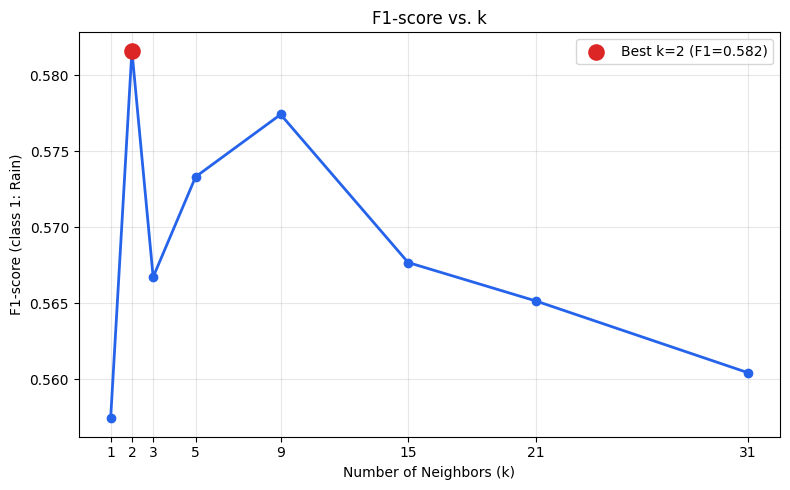

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, f1_scores, marker='o', color='#2563eb', linewidth=2)

bi = int(np.argmax(f1_scores))
plt.scatter(k_values[bi], f1_scores[bi], color='#dc2626', s=120, zorder=5,
            label=f'Best k={k_values[bi]} (F1={f1_scores[bi]:.3f})')

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('F1-score (class 1: Rain)')
plt.title('F1-score vs. k')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### To Answer The Question At The End Of The Practice
for the prediction of the tomorrow's rain for real time in least possible time, which algorithm works? 
- decision tree
- KNN
Why? 

to answer this question i can see the main algorithm's measure for the questioner is "`to be real time`"!<br>
and that's mean it is ok to be slow in training part, but in test section it must be fast.<br>
in this case `decision tree` is the better algorithm, <br>
you see, the order of the eager learner like decision tree is the depth of the tree -> `O(log n)`<br>
but in KNN , it is a lazy learner and it gets bigger with getting more data -> `O(n * d)` d = feature's number, n = data's number